# Model 3: Dense Model (Window=30, Horizon=7)
This notebook demonstrates a dense neural network for Bitcoin price prediction using a window of 30 days to predict the next 7 days.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# Load Bitcoin historical data
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv

df = pd.read_csv('BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv', parse_dates=['Date'], index_col=['Date'])
bitcoin_prices = pd.DataFrame(df['Closing Price (USD)']).rename(columns={'Closing Price (USD)': 'Price'})
prices = bitcoin_prices['Price'].to_numpy()

--2025-10-22 00:41:24--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178509 (174K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 174.33K  --.-KB/s    in 0.02s   

2025-10-22 00:41:24 (10.9 MB/s) - ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’ saved [178509/178509]



In [3]:
# Utility function for plotting
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
    plt.plot(timesteps[start:end], values[start:end], format, label=label)
    plt.xlabel('Time')
    plt.ylabel('BTC Price')
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)

In [4]:
# Windowing functions
def get_labelled_windows(x, horizon=7):
    return x[:, :-horizon], x[:, -horizon:]
def make_windows(x, window_size=30, horizon=7):
    window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
    window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T
    windowed_array = x[window_indexes]
    windows, labels = get_labelled_windows(windowed_array, horizon=horizon)
    return windows, labels
def make_train_test_splits(windows, labels, test_split=0.2):
    split_size = int(len(windows) * (1-test_split))
    train_windows = windows[:split_size]
    train_labels = labels[:split_size]
    test_windows = windows[split_size:]
    test_labels = labels[split_size:]
    return train_windows, test_windows, train_labels, test_labels

In [5]:
# Prepare windowed data
HORIZON = 7
WINDOW_SIZE = 30
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)

## Build and Train Dense Model

In [6]:
from tensorflow.keras import layers
tf.random.set_seed(42)
model_3 = tf.keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.Dense(HORIZON)
], name='model_3_dense')
model_3.compile(loss='mae', optimizer=tf.keras.optimizers.Adam())
model_3.fit(train_windows, train_labels, batch_size=128, epochs=100, verbose=0, validation_data=(test_windows, test_labels))

## Evaluate Model

In [7]:
model_3.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 633.5825 


1258.738037109375

In [8]:
# Make predictions
def make_preds(model, input_data):
    forecast = model.predict(input_data)
    return tf.squeeze(forecast)
model_3_preds = make_preds(model_3, test_windows)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [12]:
# Evaluation metrics
def mean_absolute_scaled_error(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1]))
    return mae / mae_naive_no_season
def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae_metric  = tf.keras.metrics.MeanAbsoluteError()
    mse_metric  = tf.keras.metrics.MeanSquaredError()
    mape_metric = tf.keras.metrics.MeanAbsolutePercentageError()

    mae_metric.update_state(y_true, y_pred)
    mse_metric.update_state(y_true, y_pred)
    mape_metric.update_state(y_true, y_pred)

    rmse = tf.sqrt(mse_metric.result())
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        "mae": mae_metric.result().numpy(),
        "mse": mse_metric.result().numpy(),
        "rmse": rmse.numpy(),
        "mape": mape_metric.result().numpy(),
        "mase": mase.numpy()
    }

In [13]:
model_3_results = evaluate_preds(y_true=tf.squeeze(test_labels), y_pred=model_3_preds)
print(model_3_results)

{'mae': np.float32(1258.7383), 'mse': np.float32(5374870.0), 'rmse': np.float32(2318.3767), 'mape': np.float32(5.6671267), 'mase': np.float32(2.239854)}


## Visualize Predictions

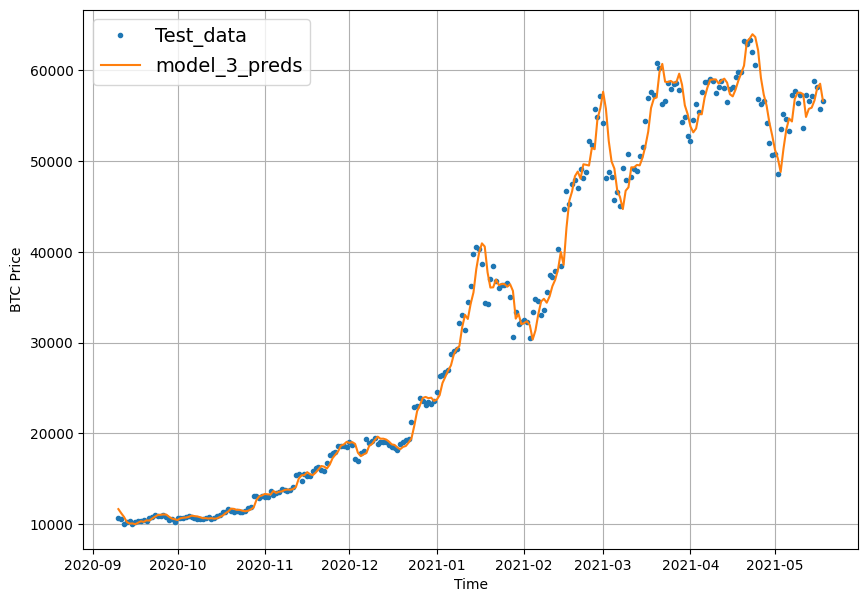

In [14]:
offset = 300
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=bitcoin_prices.index[-len(test_windows):], values=test_labels[:, 0], start=offset, label='Test_data')
plot_time_series(timesteps=bitcoin_prices.index[-len(test_windows):], values=tf.reduce_mean(model_3_preds, axis=1), start=offset, format='-', label='model_3_preds')